# Importing libraries and data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

START_DATE = '2010-01-01'   # start of data download
TRAIN_END  = '2022-12-31'   # end of training period
TEST_START = '2023-01-01'   # start of test period
END_DATE   = '2025-12-31'   # end of data download
K          = 30             # number of stocks to select each quarter


In [2]:
# Get S&P 500 list from Wikipedia 
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
table = BeautifulSoup(resp.text, 'lxml').find('table', {'id': 'constituents'})
sp500 = pd.read_html(str(table))[0][['Symbol', 'Security', 'GICS Sector']]
sp500.columns = ['ticker', 'company', 'sector']
sp500['ticker'] = sp500['ticker'].str.replace('.', '-', regex=False)
print(f'Found {len(sp500)} S&P 500 stocks.')

# Download market caps to find the top 100 
caps = {}
for ticker in sp500['ticker']:
    try:
        caps[ticker] = getattr(yf.Ticker(ticker).fast_info, 'market_cap', None)
    except:
        caps[ticker] = None

sp500['market_cap'] = sp500['ticker'].map(caps)
top100 = (sp500.dropna(subset=['market_cap'])
               .sort_values('market_cap', ascending=False)
               .head(100)
               .reset_index(drop=True))

top100.to_csv('data/metadata.csv', index=False)
print(f'\nTop 100 selected. Sector breakdown:')
print(top100['sector'].value_counts().to_string())

Found 503 S&P 500 stocks.

Top 100 selected. Sector breakdown:
sector
Information Technology    27
Financials                17
Health Care               13
Industrials               12
Communication Services     8
Consumer Discretionary     8
Consumer Staples           7
Energy                     3
Materials                  2
Real Estate                2
Utilities                  1


In [3]:
tickers    = top100['ticker'].tolist()
sector_map = top100.set_index('ticker')['sector'].to_dict()

print(f'Downloading prices for {len(tickers)} stocks...')
raw = yf.download(tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=True)

prices = raw['Close'].copy()
volume = raw['Volume'].copy()

# ── Drop stocks with >10% missing data, forward-fill short gaps ──────────────
missing = prices.isna().mean()
to_drop = missing[missing > 0.10].index.tolist()
if to_drop:
    print(f'Dropping {len(to_drop)} stocks with >10% missing: {to_drop}')
    prices = prices.drop(columns=to_drop)
    volume = volume.drop(columns=to_drop)

prices = prices.ffill(limit=5).bfill(limit=5)
volume = volume.ffill(limit=5).bfill(limit=5)

# Download S&P 500 index (benchmark) and VIX
index_prices  = yf.download('^GSPC', start=START_DATE, end=END_DATE,
                             auto_adjust=True, progress=False)['Close'].squeeze()
vix           = yf.download('^VIX',  start=START_DATE, end=END_DATE,
                             auto_adjust=True, progress=False)['Close'].squeeze()

# Compute the log returns
returns       = np.log(prices / prices.shift(1)).dropna()
index_returns = np.log(index_prices / index_prices.shift(1)).dropna()
index_returns.name = 'SP500'

# Align all series to common trading dates 
common = returns.index.intersection(index_returns.index).intersection(vix.index)
returns       = returns.loc[common]
index_returns = index_returns.loc[common]
vix           = vix.loc[common]

N       = len(returns.columns)
tickers = returns.columns.tolist()
print(f'\nFinal universe: {N} stocks')
print(f'Date range: {common[0].date()} to {common[-1].date()}')

[*********************100%***********************]  100 of 100 completed


Dropping 11 stocks with >10% missing: ['ABBV', 'ANET', 'APP', 'DELL', 'GEV', 'META', 'PANW', 'PLTR', 'SNDK', 'UBER', 'VRT']

Final universe: 89 stocks
Date range: 2010-06-23 to 2025-12-30


In [4]:
train = returns.index <= TRAIN_END
test  = returns.index >= TEST_START

returns_train       = returns[train]
index_returns_train = index_returns[train]
vix_train           = vix[train]

print(f'Training: {returns_train.index[0].date()} → {returns_train.index[-1].date()} ({train.sum()} days)')
print(f'Test:     {returns[test].index[0].date()} → {returns[test].index[-1].date()} ({test.sum()} days)')

Training: 2010-06-23 → 2022-12-30 (3154 days)
Test:     2023-01-03 → 2025-12-30 (751 days)


In [5]:
def score_stocks(ret_window, idx_window, vol_window,
                 w_T=3.0, w_M=1.0, w_L=1.5):
    """
    Score each stock from 0 to 1 on three factors.
    Returns a Series: ticker -> combined score (higher = better).
    """
    # Tracking quality = correlation with index × penalty if beta ≠ 1
    # (beta = how much the stock moves relative to the index)
    corr     = ret_window.corrwith(idx_window).fillna(0)
    beta     = (ret_window.apply(lambda c: c.cov(idx_window)) / idx_window.var()).fillna(1)
    tq       = (corr * np.exp(-np.abs(beta - 1))).clip(0)   # clip negatives to 0

    # Momentum = 12-month return (excluding last month to avoid reversal)
    lookback = ret_window.iloc[-252:-21] if len(ret_window) >= 252 else ret_window
    mom_raw  = lookback.sum()
    denom    = mom_raw.max() - mom_raw.min()
    mom      = (mom_raw - mom_raw.min()) / denom if denom > 0 else mom_raw * 0

    # Liquidity = average daily volume (normalised)
    avg_vol = vol_window.mean()
    liq     = avg_vol / avg_vol.max() if avg_vol.max() > 0 else avg_vol * 0

    # Align all to same tickers
    idx = ret_window.columns
    combined = w_T * tq.reindex(idx).fillna(0) \
             + w_M * mom.reindex(idx).fillna(0) \
             + w_L * liq.reindex(idx).fillna(0)

    return combined   # higher = better stock for tracking


# Test on training data
vol_train = volume.loc[returns_train.index]
scores_example = score_stocks(returns_train, index_returns_train, vol_train)

print('Top 10 stocks by score (training period):')
print(scores_example.sort_values(ascending=False).head(10).round(3).to_string())

Top 10 stocks by score (training period):
Ticker
AAPL     2.976
HON      2.882
BRK-B    2.859
CVX      2.820
XOM      2.804
RTX      2.765
NVDA     2.690
V        2.631
LIN      2.627
DE       2.621


In [6]:
def select_portfolio_greedy(scores, corr_matrix, gamma, tickers,
                             sector_map, K=30,
                             max_sector_frac=0.25, min_sectors=6):
    """
    Greedily select K stocks by minimising Ising energy.

    At each step we pick the candidate stock that gives the
    largest decrease in:
        Energy = -score(stock) + gamma * sum(correlation with already-selected stocks)

    gamma controls the diversification pressure:
        - High gamma → strongly avoids correlated stocks → more diversified
        - Low gamma  → cares less about correlation → less diversified

    Sector constraints applied at the end (same as paper Section III.E.1).
    """
    max_per_sector = max(1, int(np.ceil(K * max_sector_frac)))
    remaining      = list(tickers)
    selected       = []
    sector_counts  = {}

    for _ in range(K):
        best_ticker = None
        best_delta  = np.inf

        for ticker in remaining:
            # Energy reduction from adding this stock:
            #   gain from its quality score
            #   minus penalty for its correlation with already-selected stocks
            gain    = -scores.get(ticker, 0)
            penalty = gamma * sum(
                corr_matrix.loc[ticker, s]
                for s in selected
                if ticker in corr_matrix.index and s in corr_matrix.columns
            )
            delta = gain + penalty

            # Apply sector cap
            sector = sector_map.get(ticker, 'Unknown')
            if sector_counts.get(sector, 0) >= max_per_sector:
                continue  # skip if sector is full

            if delta < best_delta:
                best_delta  = delta
                best_ticker = ticker

        # Fallback: if all sectors are full, pick best regardless
        if best_ticker is None:
            best_ticker = min(
                remaining,
                key=lambda t: -scores.get(t, 0) + gamma * sum(
                    corr_matrix.loc[t, s]
                    for s in selected
                    if t in corr_matrix.index and s in corr_matrix.columns
                )
            )

        selected.append(best_ticker)
        remaining.remove(best_ticker)
        sector = sector_map.get(best_ticker, 'Unknown')
        sector_counts[sector] = sector_counts.get(sector, 0) + 1

    return selected


print('Portfolio selection function defined.')

Portfolio selection function defined.


In [7]:
def fit_hmm_and_get_stress_prob(index_returns_window):
    """
    Fit a 2-state Gaussian HMM to the index return history.
    Returns the probability that the CURRENT market state is high-volatility (stress).
    """
    X = index_returns_window.values.reshape(-1, 1)

    model = GaussianHMM(n_components=2, covariance_type='full',
                        n_iter=1000, random_state=42)
    model.fit(X)

    # Identify which state has higher variance = stress state
    vols          = [np.sqrt(model.covars_[s][0][0]) for s in range(2)]
    stress_state  = int(np.argmax(vols))

    # Get the posterior probability of each state for the LAST observation
    posteriors    = model.predict_proba(X)
    stress_prob   = float(posteriors[-1, stress_state])

    return stress_prob

def compute_vix_gamma(vix_level, gamma0=0.5, V0=20.0,
                       gamma_min=0.1, gamma_max=0.8):
    """
    Original paper's method: coupling strength based on VIX level.
    Higher VIX → lower gamma (less diversification pressure).
    """
    gamma = gamma0 * np.exp(-0.5 * (vix_level / V0 - 1))
    return float(np.clip(gamma, gamma_min, gamma_max))

def compute_hmm_gamma(stress_prob, gamma_low=0.6, gamma_high=0.1):
    """
    Our extension: coupling strength based on HMM stress probability.
    Higher stress probability → lower gamma (less diversification pressure).
    """
    gamma = gamma_low + stress_prob * (gamma_high - gamma_low)
    return float(np.clip(gamma, gamma_high, gamma_low))

print('HMM and coupling functions defined.')

# Quick demo
stress_prob_demo = fit_hmm_and_get_stress_prob(index_returns_train)
print(f'\nCurrent stress probability (end of training): {stress_prob_demo:.1%}')
print(f'  → VIX-based gamma:  {compute_vix_gamma(vix_train.iloc[-1]):.3f}')
print(f'  → HMM-based gamma:  {compute_hmm_gamma(stress_prob_demo):.3f}')

HMM and coupling functions defined.

Current stress probability (end of training): 70.3%
  → VIX-based gamma:  0.480
  → HMM-based gamma:  0.249


In [8]:
# Get the first trading day of each quarter in the test period
test_dates      = returns.loc[TEST_START:].index
quarter_starts  = []
current_q       = None
for date in test_dates:
    q = (date.year, (date.month - 1) // 3)
    if q != current_q:
        quarter_starts.append(date)
        current_q = q

print(f'Rebalancing on {len(quarter_starts)} quarters:')
for d in quarter_starts:
    print(f'  {d.date()}')

Rebalancing on 12 quarters:
  2023-01-03
  2023-04-03
  2023-07-03
  2023-10-02
  2024-01-02
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-02
  2025-04-01
  2025-07-01
  2025-10-01


In [9]:
# Run the quarterly loop
WINDOW = 252 * 3   # 3-year rolling window

vix_records = []   # stores results for VIX method
hmm_records = []   # stores results for HMM method

for q_idx, rebal_date in enumerate(quarter_starts):
    print(f'Quarter {q_idx+1}/{len(quarter_starts)}: {rebal_date.date()}', end=' ... ')

    # 1. Slice the rolling training window
    ret_w = returns.loc[:rebal_date].iloc[-(WINDOW+1):-1]
    idx_w = index_returns.loc[:rebal_date].iloc[-(WINDOW+1):-1]
    vol_w = volume.loc[:rebal_date].iloc[-(WINDOW+1):-1]

    # 2. Score stocks and compute correlation matrix
    scores      = score_stocks(ret_w, idx_w, vol_w).to_dict()
    corr_matrix = ret_w.corr()

    # 3a. VIX-based gamma (original paper method)
    current_vix = float(vix.asof(rebal_date))
    gamma_vix   = compute_vix_gamma(current_vix)

    # 3b. HMM-based gamma (our extension)
    stress_prob  = fit_hmm_and_get_stress_prob(idx_w)
    gamma_hmm    = compute_hmm_gamma(stress_prob)

    print(f'VIX={current_vix:.1f} γ_vix={gamma_vix:.3f} | stress={stress_prob:.1%} γ_hmm={gamma_hmm:.3f}')

    # 4. Select 30 stocks using each method
    sel_vix = select_portfolio_greedy(scores, corr_matrix, gamma_vix,
                                       tickers, sector_map, K=K)
    sel_hmm = select_portfolio_greedy(scores, corr_matrix, gamma_hmm,
                                       tickers, sector_map, K=K)

    # 5. Define holding period (until next rebalancing date)
    if q_idx + 1 < len(quarter_starts):
        next_q = quarter_starts[q_idx + 1]
        hold   = returns.loc[rebal_date:next_q].iloc[1:]
    else:
        hold   = returns.loc[rebal_date:].iloc[1:]

    # 6. Equal-weighted portfolio return each day
    vix_records.append(hold[sel_vix].mean(axis=1))
    hmm_records.append(hold[sel_hmm].mean(axis=1))


Model is not converging.  Current: 2208.2440910320233 is not greater than 2208.3286617615363. Delta is -0.0845707295129614


Quarter 1/12: 2023-01-03 ... VIX=22.9 γ_vix=0.465 | stress=0.6% γ_hmm=0.597


Model is not converging.  Current: 2252.271365504558 is not greater than 2252.306857794248. Delta is -0.035492289689955214


Quarter 2/12: 2023-04-03 ... VIX=18.5 γ_vix=0.518 | stress=3.7% γ_hmm=0.582


Model is not converging.  Current: 2312.6764117327434 is not greater than 2312.683309127667. Delta is -0.006897394923726097


...

Quarter 10/12: 2025-04-01 ... VIX=21.8 γ_vix=0.478 | stress=2.0% γ_hmm=0.590


Model is not converging.  Current: 2406.879122036525 is not greater than 2406.880645116875. Delta is -0.0015230803496706358


Quarter 11/12: 2025-07-01 ... VIX=16.8 γ_vix=0.541 | stress=0.4% γ_hmm=0.598


Model is not converging.  Current: 2474.008526547294 is not greater than 2474.0408656943014. Delta is -0.0323391470074057


Quarter 12/12: 2025-10-01 ... VIX=16.3 γ_vix=0.549 | stress=0.1% γ_hmm=0.600


In [10]:
def stitch(records, index_returns):
    s = pd.concat(records).sort_index()
    s = s[~s.index.duplicated(keep='first')]
    common = s.index.intersection(index_returns.index)
    return s.loc[common], index_returns.loc[common]

vix_ret, idx_test = stitch(vix_records, index_returns)
hmm_ret, _        = stitch(hmm_records, index_returns)

# Greedy baseline
greedy_records = []
for q_idx, rebal_date in enumerate(quarter_starts):
    ret_w  = returns.loc[:rebal_date].iloc[-(WINDOW+1):-1]
    idx_w  = index_returns.loc[:rebal_date].iloc[-(WINDOW+1):-1]
    corrs  = ret_w.corrwith(idx_w)
    sel    = corrs.nlargest(K).index.tolist()
    next_q = quarter_starts[q_idx + 1] if q_idx + 1 < len(quarter_starts) else None
    hold   = returns.loc[rebal_date:next_q].iloc[1:] if next_q else returns.loc[rebal_date:].iloc[1:]
    greedy_records.append(hold[sel].mean(axis=1))

greedy_ret, _ = stitch(greedy_records, index_returns)

print(f'Test period: {idx_test.index[0].date()} to {idx_test.index[-1].date()}')
print(f'Days: {len(idx_test)}')

# Save return series for reproducibility
vix_ret.to_csv('results/thrml_vix_returns.csv')
hmm_ret.to_csv('results/thrml_hmm_returns.csv')
greedy_ret.to_csv('results/greedy_returns.csv')
print('Saved return series to results/')

Test period: 2023-01-04 to 2025-12-30
Days: 750
Saved return series to results/


In [11]:
# Stitch quarterly returns into one continuous series
def compute_metrics(port, benchmark, label, rf=0.02/252):
    common = port.index.intersection(benchmark.index)
    p, b   = port.loc[common], benchmark.loc[common]

    te       = (p - b).std() * np.sqrt(252) * 100
    corr     = p.corr(b)
    total    = ((1 + p).prod() - 1) * 100
    sharpe   = (p - rf).mean() / (p - rf).std() * np.sqrt(252)
    active   = p - b
    ir       = active.mean() / active.std() * np.sqrt(252)
    cum      = (1 + p).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min() * 100

    return {'Method': label, 'Tracking Error': f'{te:.2f}%',
            'Correlation': f'{corr:.4f}', 'Total Return': f'{total:.2f}%',
            'Sharpe': f'{sharpe:.2f}', 'Info Ratio': f'{ir:.2f}',
            'Max Drawdown': f'{max_dd:.2f}%'}

results = pd.DataFrame([
    compute_metrics(vix_ret,    idx_test, 'THRML-VIX (replication)'),
    compute_metrics(hmm_ret,    idx_test, 'THRML-HMM (our extension)'),
    compute_metrics(greedy_ret, idx_test, 'Greedy baseline'),
    {'Method': 'THRML (paper)', 'Tracking Error': '4.31%', 'Correlation': '0.9582',
     'Total Return': '128.63%', 'Sharpe': '1.87', 'Info Ratio': '1.85', 'Max Drawdown': '-17.09%'},
    {'Method': 'Greedy (paper)', 'Tracking Error': '6.30%', 'Correlation': '0.9456',
     'Total Return': '115.95%', 'Sharpe': '1.40', 'Info Ratio': '1.06', 'Max Drawdown': '-21.30%'},
])

print('\n=== OUT-OF-SAMPLE PERFORMANCE (2023–2025) ===')
print(results.to_string(index=False))
results.to_csv('results/performance_metrics.csv', index=False)



=== OUT-OF-SAMPLE PERFORMANCE (2023–2025) ===
                   Method Tracking Error Correlation Total Return Sharpe Info Ratio Max Drawdown
  THRML-VIX (replication)          5.84%      0.9216       76.07%   1.32       0.02      -16.18%
THRML-HMM (our extension)          5.98%      0.9177       74.11%   1.30      -0.04      -16.61%
          Greedy baseline          7.45%      0.9564      122.13%   1.32       1.22      -24.83%
            THRML (paper)          4.31%      0.9582      128.63%   1.87       1.85      -17.09%
           Greedy (paper)          6.30%      0.9456      115.95%   1.40       1.06      -21.30%


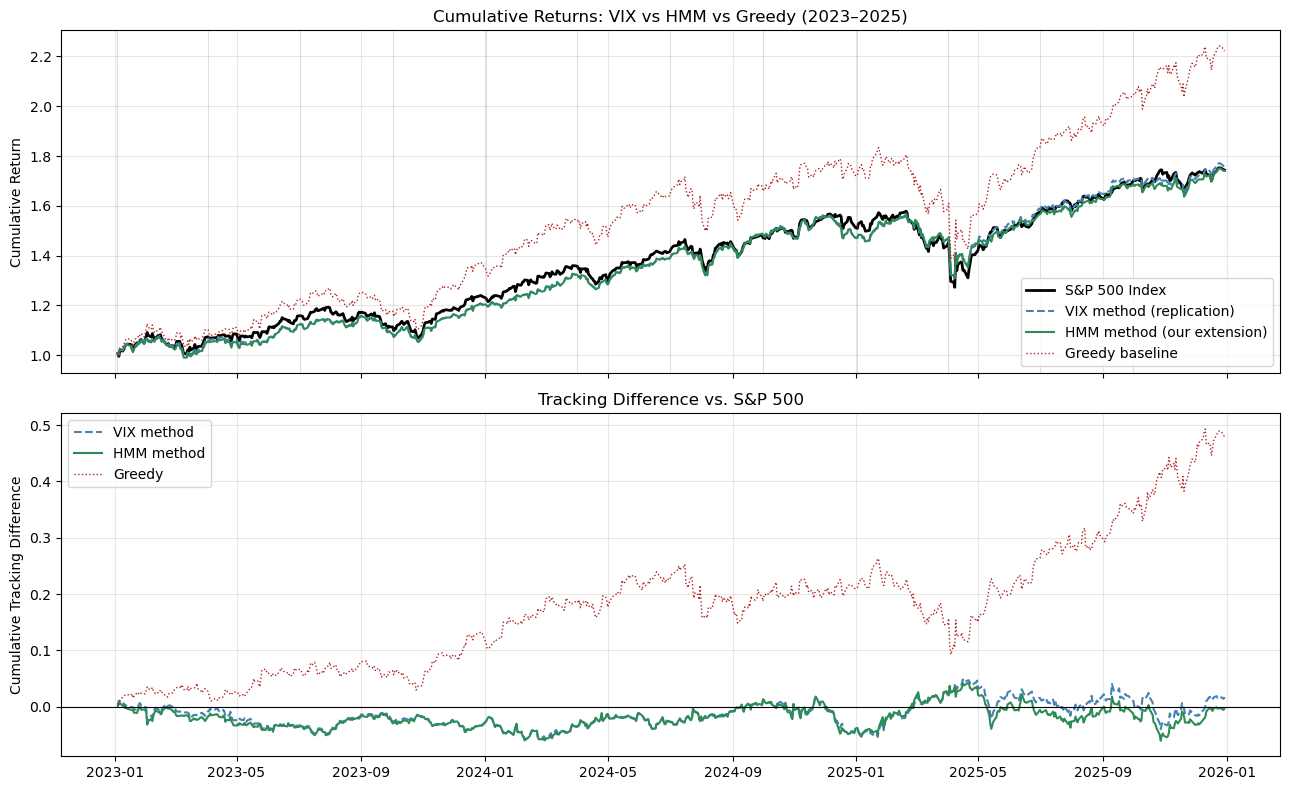

Saved: results/cumulative_returns.png


In [12]:
# Chart 1: Cumulative returns 
common_all = vix_ret.index.intersection(hmm_ret.index).intersection(idx_test.index)

cum_vix    = (1 + vix_ret.loc[common_all]).cumprod()
cum_hmm    = (1 + hmm_ret.loc[common_all]).cumprod()
cum_greedy = (1 + greedy_ret.loc[common_all]).cumprod()
cum_index  = (1 + idx_test.loc[common_all]).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: cumulative returns
axes[0].plot(cum_index,  color='black',     lw=2,   label='S&P 500 Index')
axes[0].plot(cum_vix,    color='steelblue', lw=1.5, linestyle='--', label='VIX method (replication)')
axes[0].plot(cum_hmm,    color='seagreen',  lw=1.5, linestyle='-',  label='HMM method (our extension)')
axes[0].plot(cum_greedy, color='firebrick', lw=1.0, linestyle=':',  label='Greedy baseline')
for rd in quarter_starts:
    axes[0].axvline(rd, color='gray', alpha=0.25, lw=0.8)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Cumulative Returns: VIX vs HMM vs Greedy (2023–2025)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: tracking difference vs index
axes[1].plot(cum_vix    - cum_index, color='steelblue', lw=1.5, linestyle='--', label='VIX method')
axes[1].plot(cum_hmm    - cum_index, color='seagreen',  lw=1.5, label='HMM method')
axes[1].plot(cum_greedy - cum_index, color='firebrick', lw=1.0, linestyle=':', label='Greedy')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Cumulative Tracking Difference')
axes[1].set_title('Tracking Difference vs. S&P 500')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/cumulative_returns.png', dpi=150)
plt.show()
print('Saved: results/cumulative_returns.png')

HMM State 0 (Bull):   vol = 11.0% ann.
HMM State 1 (Stress): vol = 30.7% ann.


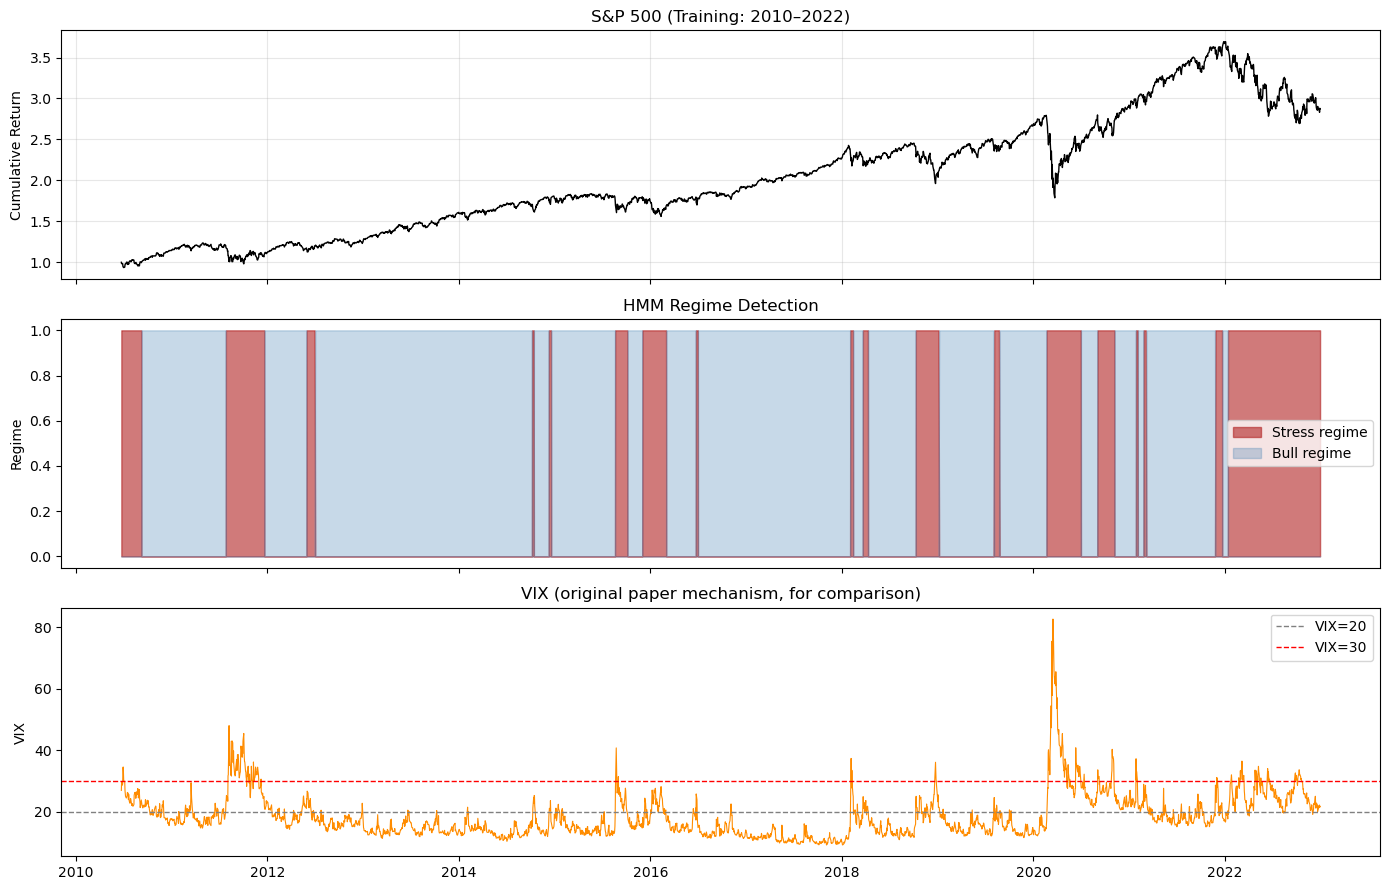

Saved: results/hmm_regimes.png


In [13]:
# Chart 2: HMM Regime Detection on Training Data
# Fit HMM on full training set for visualisation
X          = index_returns_train.values.reshape(-1, 1)
hmm_full   = GaussianHMM(n_components=2, covariance_type='full',
                          n_iter=500, random_state=42).fit(X)
vols_full  = [np.sqrt(hmm_full.covars_[s][0][0]) for s in range(2)]
stress_s   = int(np.argmax(vols_full))
states     = hmm_full.predict(X)
regime     = pd.Series(states, index=index_returns_train.index)

print(f'HMM State {1-stress_s} (Bull):   vol = {vols_full[1-stress_s]*np.sqrt(252)*100:.1f}% ann.')
print(f'HMM State {stress_s} (Stress): vol = {vols_full[stress_s]*np.sqrt(252)*100:.1f}% ann.')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1: S&P 500
cum_train = (1 + index_returns_train).cumprod()
axes[0].plot(cum_train, color='black', lw=1)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('S&P 500 (Training: 2010–2022)')
axes[0].grid(alpha=0.3)

# Panel 2: HMM regimes
axes[1].fill_between(regime.index, (regime == stress_s).astype(int),
                     color='firebrick', alpha=0.6, label='Stress regime')
axes[1].fill_between(regime.index, (regime != stress_s).astype(int),
                     color='steelblue', alpha=0.3, label='Bull regime')
axes[1].set_ylabel('Regime')
axes[1].set_title('HMM Regime Detection')
axes[1].legend()

# Panel 3: VIX for comparison
axes[2].plot(vix_train, color='darkorange', lw=0.8)
axes[2].axhline(20, color='gray', linestyle='--', lw=1, label='VIX=20')
axes[2].axhline(30, color='red',  linestyle='--', lw=1, label='VIX=30')
axes[2].set_ylabel('VIX')
axes[2].set_title('VIX (original paper mechanism, for comparison)')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/hmm_regimes.png', dpi=150)
plt.show()
print('Saved: results/hmm_regimes.png')

Model is not converging.  Current: 2208.2440910320233 is not greater than 2208.3286617615363. Delta is -0.0845707295129614
Model is not converging.  Current: 2252.271365504558 is not greater than 2252.306857794248. Delta is -0.035492289689955214
Model is not converging.  Current: 2312.6764117327434 is not greater than 2312.683309127667. Delta is -0.006897394923726097
Model is not converging.  Current: 2329.7915749563317 is not greater than 2329.797494467412. Delta is -0.005919511080264783
Model is not converging.  Current: 2342.3717972242707 is not greater than 2342.38358938404. Delta is -0.011792159769356658
Model is not converging.  Current: 2357.2063897019134 is not greater than 2357.207288070716. Delta is -0.0008983688026091841
Model is not converging.  Current: 2349.3260788033094 is not greater than 2349.377676188764. Delta is -0.0515973854544427
Model is not converging.  Current: 2370.9574358974633 is not greater than 2371.0402391496896. Delta is -0.0828032522263129
Model is not 

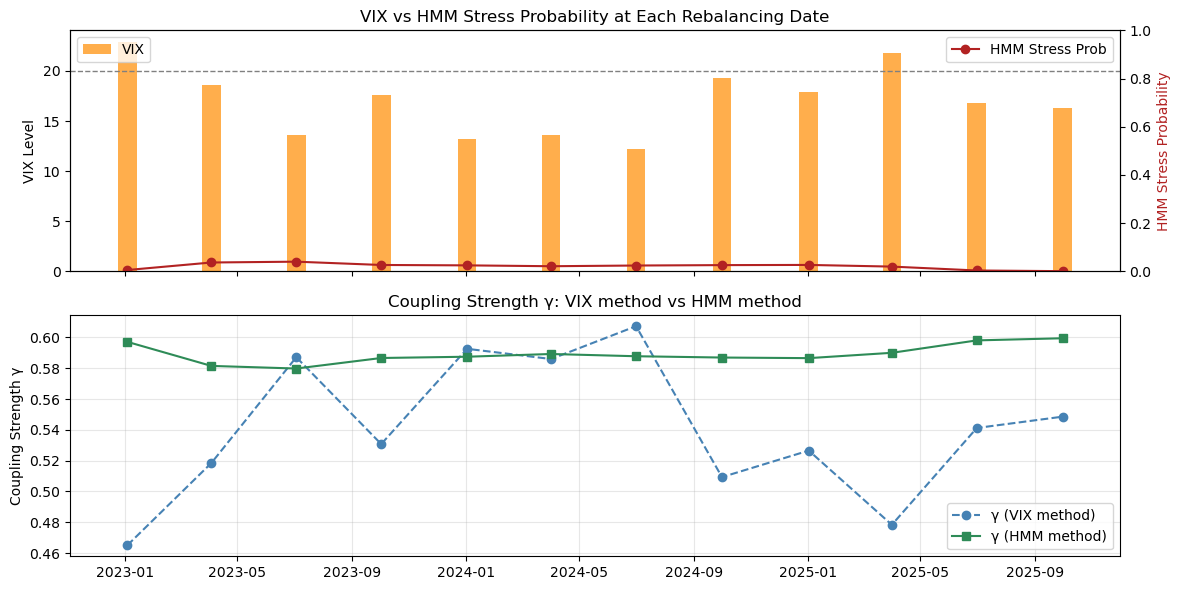

Saved: results/gamma_comparison.png


In [14]:
# Chart 3: VIX vs HMM gamma over time
quarter_info = []
for rebal_date in quarter_starts:
    idx_w       = index_returns.loc[:rebal_date].iloc[-(WINDOW+1):-1]
    vix_val     = float(vix.asof(rebal_date))
    stress_p    = fit_hmm_and_get_stress_prob(idx_w)
    quarter_info.append({
        'date'       : rebal_date,
        'vix'        : vix_val,
        'stress_prob': stress_p,
        'gamma_vix'  : compute_vix_gamma(vix_val),
        'gamma_hmm'  : compute_hmm_gamma(stress_p),
    })

qi = pd.DataFrame(quarter_info).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(qi.index, qi['vix'], width=20, color='darkorange', alpha=0.7, label='VIX')
axes[0].axhline(20, color='gray', linestyle='--', lw=1)
axes[0].set_ylabel('VIX Level')
axes[0].set_title('VIX vs HMM Stress Probability at Each Rebalancing Date')
ax2 = axes[0].twinx()
ax2.plot(qi.index, qi['stress_prob'], 'o-', color='firebrick', lw=1.5, label='HMM Stress Prob')
ax2.set_ylabel('HMM Stress Probability', color='firebrick')
ax2.set_ylim(0, 1)
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

axes[1].plot(qi.index, qi['gamma_vix'], 'o--', color='steelblue', lw=1.5, label='γ (VIX method)')
axes[1].plot(qi.index, qi['gamma_hmm'], 's-',  color='seagreen',  lw=1.5, label='γ (HMM method)')
axes[1].set_ylabel('Coupling Strength γ')
axes[1].set_title('Coupling Strength γ: VIX method vs HMM method')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/gamma_comparison.png', dpi=150)
plt.show()
print('Saved: results/gamma_comparison.png')
